## JEPA-SCORE implementation

In [2]:
import torch
from torch.utils.data import DataLoader, Subset, Dataset
from torch.autograd.functional import jacobian

import torch.nn as nn
import timm
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from timm.utils import AttentionExtract
from torchvision import transforms
from timm.data import create_transform
from typing import Dict
from torch.nn import functional as F
import os
from tqdm import tqdm
import re
import pandas as pd

from sklearn.metrics import (
    f1_score,
    accuracy_score,
    roc_auc_score,
    average_precision_score,
)

### Check if GPU is available

In [3]:
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} is available.")
else:
    print("No GPU available. Training will run on CPU.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

GPU: NVIDIA GeForce RTX 4090 is available.
cuda


### Prepare model

In [3]:
timm.layers.set_fused_attn(False) # makes score calculation faster
 
# Load the pre-trained DINOv2 model
# implementation based on https://huggingface.co/timm/vit_large_patch14_dinov2.lvd142m
# 'vit_large_patch14_dinov2.lvd142m'
# 'vit_small_patch14_dinov2.lvd142m'
# 'vit_base_patch14_dinov2.lvd142m'

model = timm.create_model('vit_small_patch14_dinov2.lvd142m', pretrained=True, num_classes=0) # num_classes is important, as we want the input Jacobian w.r.t. to the embeddings and not output logits
model.eval()

model = model.to(device)

# get model specific transforms (normalization, resize)
data_config = timm.data.resolve_model_data_config(model)
transforms = timm.data.create_transform(**data_config, is_training=False)

### Prepare datasets

In [4]:
class CustomImageDataset(Dataset):
    def __init__(self, annotations_file: pd.DataFrame, img_dir: str, transform=None, target_transform=None):
        self.img_labels = annotations_file
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = Image.open(img_path).convert("RGB")
        label = self.img_labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        return image, label, img_path


In [5]:
""" path_val = "./datasets/COCO_official/val2017"
dir_list_val = os.listdir(path_val)

val_set_paths_labels = pd.DataFrame({
    "path": dir_list_val,
    "label": np.zeros(len(dir_list_val), dtype=float)
})

val_set_paths_labels.head() """

' path_val = "./datasets/COCO_official/val2017"\ndir_list_val = os.listdir(path_val)\n\nval_set_paths_labels = pd.DataFrame({\n    "path": dir_list_val,\n    "label": np.zeros(len(dir_list_val), dtype=float)\n})\n\nval_set_paths_labels.head() '

In [5]:
path_test = "./datasets/test_sets/CNNSpot/all"
dir_list_test = os.listdir(path_test)

test_set_paths_labels = pd.DataFrame({
    "path": dir_list_test,
    "label": [
        float(0) if name.startswith("real")
        else float(1) if name.startswith("fake")
        else None
        for name in dir_list_test
    ]
})

test_set_paths_labels.head()

,path,label
0,fake_test_stylegan_cat_1_fake_098938.png,1.0
1,real_train_cow_0_real_00882.png,0.0
2,fake_test_stylegan_cat_1_fake_094685.png,1.0
3,fake_train_bus_1_fake_00765.png,1.0
4,fake_test_gaugan_1_fake_000000164883.png,1.0


In [6]:
test_set_paths_labels.label.value_counts()

label
1.0    68119
0.0    26070
Name: count, dtype: int64

In [7]:
#val_dataset = CustomImageDataset(val_set_paths_labels, path_val, transform=transforms)
test_dataset = CustomImageDataset(test_set_paths_labels, path_test, transform=transforms)

In [9]:
""" val_loader = DataLoader(dataset=val_dataset, batch_size=4, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=4, shuffle=False) """

' val_loader = DataLoader(dataset=val_dataset, batch_size=4, shuffle=False)\ntest_loader = DataLoader(dataset=test_dataset, batch_size=4, shuffle=False) '

In [ ]:
labels = np.array(test_dataset.img_labels)   # adapt if labels stored differently

class0_idx = np.where(labels == 0)[0]
class1_idx = np.where(labels == 1)[0]

n = min(len(class0_idx), len(class1_idx))

# randomly choose same number from each class
selected0 = np.random.choice(class0_idx, n, replace=False)
selected1 = np.random.choice(class1_idx, n, replace=False)

balanced_indices = np.concatenate([selected0, selected1])
np.random.shuffle(balanced_indices)

balanced_test_dataset = Subset(test_dataset, balanced_indices)

#balanced_dataloader = DataLoader(dataset=balanced_test_dataset, batch_size=4, shuffle=False)


In [9]:
len(balanced_test_dataset)

52140

In [11]:
calculated = pd.read_csv("test_jepa_scores.csv")
len(calculated)

11136

In [ ]:
balanced_new = balanced_test_dataset[~balanced_test_dataset['path'].isin(calculated['path'])]
len(balanced_new)

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

### Compute JEPA-SCORES

this is way too slow!!

2. test approximations of Jacobian

## !! implement checkpoint to not loose all results if sth. breaks over the weekend
might use this: https://huggingface.co/docs/accelerate/en/usage_guides/checkpoint

In [ ]:
# Listing 1: JEPA-SCORE implementation in PyTorch. Our empirical ablations demonstrate that JEPA-SCORE is not sensitive to the choice of eps (we pick 1​e−6)
eps = 1e-6

torch.set_grad_enabled(True)
model.requires_grad_(False)

#results = []

csv_path = "test_jepa_scores.csv"
write_header = not os.path.exists(csv_path)

for i, (img, label, img_path) in tqdm(enumerate(balanced_dataloader), total=len(balanced_dataloader), desc="Computing JEPA scores"):
    img = img.to(device).requires_grad_(True)    # shape: [batch size, C, H, W]
    # label = label.item()    # shape: [1, batch size]; 0 = "real"; 1 = "fake"
    # img_path                # shape: (batch size)

    # Compute Jacobian for single image
    J = jacobian(lambda x: model(x).sum(0), inputs=img)
    with torch.inference_mode():
        J = J.flatten(2).permute(1,0,2)
        svdvals = torch.linalg.svdvals(J)
        jepa_score = svdvals.clip_(eps).log_().sum(1) # one score per image in batch

    """     for l, s, i in zip(label.cpu().tolist(), jepa_score.cpu().tolist(), list(img_path)):
        results.append({
            "label": l,
            "score": s,
            "img_path": i
        }) """
    
    batch_results = pd.DataFrame({
        "label": label.cpu().tolist(),
        "score": jepa_score.cpu().tolist(),
        "img_path": list(img_path)
    })

    # adds the new results to the end of the csv file
    batch_results.to_csv(
        csv_path,
        mode="a",
        header=write_header,
        index=False
    )
    write_header = False

""" results_df = pd.DataFrame(results)

results_df.to_csv('val_jepa_scores.csv', index=False) """

Computing JEPA scores:   5%|▌         | 663/13035 [2:53:22<53:55:49, 15.69s/it]

In [10]:
pd.DataFrame(results)

,label,score,img_path
0,0.0,-310.120636,./datasets/COCO_official/val2017/000000431568.jpg
1,0.0,80.066925,./datasets/COCO_official/val2017/000000563281.jpg
2,0.0,-199.607590,./datasets/COCO_official/val2017/000000442822.jpg
3,0.0,49.541161,./datasets/COCO_official/val2017/000000360943.jpg
4,0.0,-248.862885,./datasets/COCO_official/val2017/000000057232.jpg
5,0.0,-172.508255,./datasets/COCO_official/val2017/000000338532.jpg
6,0.0,82.936493,./datasets/COCO_official/val2017/000000105335.jpg
7,0.0,203.873123,./datasets/COCO_official/val2017/000000023899.jpg
8,0.0,-255.300629,./datasets/COCO_official/val2017/000000174482.jpg
9,0.0,-168.691574,./datasets/COCO_official/val2017/000000041888.jpg


In [ ]:
""" from torch.profiler import profile, ProfilerActivity

with profile(activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA]) as prof:
    J = batched_jacobian(img)
    svdvals = torch.linalg.svdvals(J.flatten(2))

print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=10)) """

### Calculate threshold based on validation dataset

In [3]:
val_jepa_scores = pd.read_csv("val_jepa_scores.csv")

In [4]:
val_jepa_scores

,label,score
0,0.0,-310.120636
1,0.0,80.066925
2,0.0,-199.607590
3,0.0,49.541161
4,0.0,-248.862885
...,...,...
4995,0.0,41.569611
4996,0.0,41.514023
4997,0.0,-80.519005
4998,0.0,-206.161087


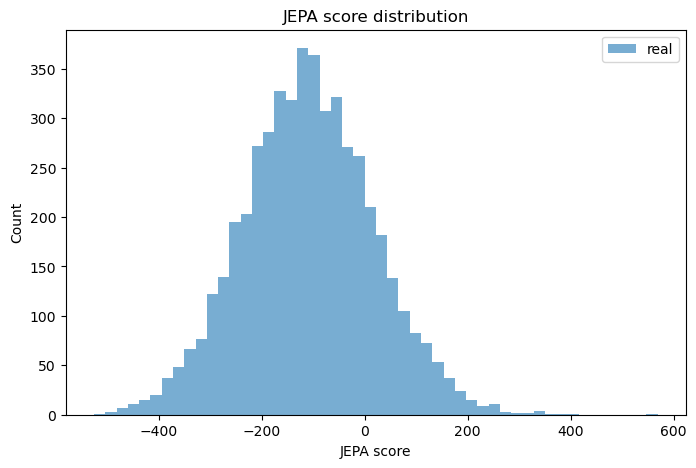

In [5]:
real_scores = val_jepa_scores.score

plt.figure(figsize=(8,5))

plt.hist(real_scores, bins=50, alpha=0.6, label="real")

plt.xlabel("JEPA score")
plt.ylabel("Count")
plt.title("JEPA score distribution")
plt.legend()

plt.show()

Note: Neighbor-based outlier detection methods could enhance prediction quality. E.g. see here: https://sustainabilitymethods.org/index.php/Outlier_Detection_in_Python

In [6]:
mean = val_jepa_scores.score.mean(numeric_only=True)
std = val_jepa_scores.score.std(numeric_only=True)

print(f"Mean: {mean}")
print(f"Standard Deviation: {std}")

mean_plus_std = mean + std
print(f"Mean + std threshold for real/fake decision: {mean_plus_std}")

mean_minus_std = mean - std
print(f"Mean - std threshold for real/fake decision: {mean_minus_std}")

percentile = val_jepa_scores.score.quantile(q=0.95)
print(f"95th percentile threshold: {percentile}")

Mean: -108.86830414581298
Standard Deviation: 127.52878395436643
Mean + std threshold for real/fake decision: 18.660479808553447
Mean - std threshold for real/fake decision: -236.39708810017942
95th percentile threshold: 105.1811660766602


In [7]:
test_results = pd.read_csv('test_jepa_scores.csv')
test_results

,label,score,img_path
0,1.0,601.173950,./datasets/test_sets/CNNSpot/all/fake_test_iml...
1,0.0,93.855659,./datasets/test_sets/CNNSpot/all/real_train_bo...
2,1.0,385.619446,./datasets/test_sets/CNNSpot/all/fake_test_iml...
3,0.0,-90.474365,./datasets/test_sets/CNNSpot/all/real_train_mo...
4,0.0,-67.452736,./datasets/test_sets/CNNSpot/all/real_train_ca...
...,...,...,...
11131,0.0,103.507927,./datasets/test_sets/CNNSpot/all/real_train_tv...
11132,0.0,201.483475,./datasets/test_sets/CNNSpot/all/real_train_ca...
11133,0.0,87.746468,./datasets/test_sets/CNNSpot/all/real_train_co...
11134,1.0,291.062012,./datasets/test_sets/CNNSpot/all/fake_test_crn...


In [8]:
# 0: real and 1: fake
test_results["prediction_mean_plus_std"] = [1 if f >= mean_plus_std else 0 for f in test_results.score]
test_results["prediction_mean_minus_std"] = [1 if f >= mean_minus_std else 0 for f in test_results.score]
test_results["prediction_percentile"] = [1 if f >= percentile else 0 for f in test_results.score]

In [9]:
test_results

,label,score,img_path,prediction_mean_plus_std,prediction_mean_minus_std,prediction_percentile
0,1.0,601.173950,./datasets/test_sets/CNNSpot/all/fake_test_iml...,1,1,1
1,0.0,93.855659,./datasets/test_sets/CNNSpot/all/real_train_bo...,1,1,0
2,1.0,385.619446,./datasets/test_sets/CNNSpot/all/fake_test_iml...,1,1,1
3,0.0,-90.474365,./datasets/test_sets/CNNSpot/all/real_train_mo...,0,1,0
4,0.0,-67.452736,./datasets/test_sets/CNNSpot/all/real_train_ca...,0,1,0
...,...,...,...,...,...,...
11131,0.0,103.507927,./datasets/test_sets/CNNSpot/all/real_train_tv...,1,1,0
11132,0.0,201.483475,./datasets/test_sets/CNNSpot/all/real_train_ca...,1,1,1
11133,0.0,87.746468,./datasets/test_sets/CNNSpot/all/real_train_co...,1,1,0
11134,1.0,291.062012,./datasets/test_sets/CNNSpot/all/fake_test_crn...,1,1,1


In [10]:
f1_mean_plus_std = f1_score(test_results.label, test_results.prediction_mean_plus_std)
acc_mean_plus_std = accuracy_score(test_results.label, test_results.prediction_mean_plus_std)

f1_mean_minus_std = f1_score(test_results.label, test_results.prediction_mean_minus_std)
acc_mean_minus_std = accuracy_score(test_results.label, test_results.prediction_mean_minus_std)

f1_percentile = f1_score(test_results.label, test_results.prediction_percentile)
acc_percentile = accuracy_score(test_results.label, test_results.prediction_percentile)

In [11]:
print("F1 (mean plus std):", f1_mean_plus_std)
print("Accuracy (mean plus std):", acc_mean_plus_std)

print("F1 (mean minus std):", f1_mean_minus_std)
print("Accuracy (mean minus std):", acc_mean_minus_std)

print("F1 (percentile):", f1_percentile)
print("Accuracy (percentile):", acc_percentile)

F1 (mean plus std): 0.7560042334934463
Accuracy (mean plus std): 0.7308728448275862
F1 (mean minus std): 0.6743383199079401
Accuracy (mean minus std): 0.5171515804597702
F1 (percentile): 0.7305544475468687
Accuracy (percentile): 0.7573635057471264


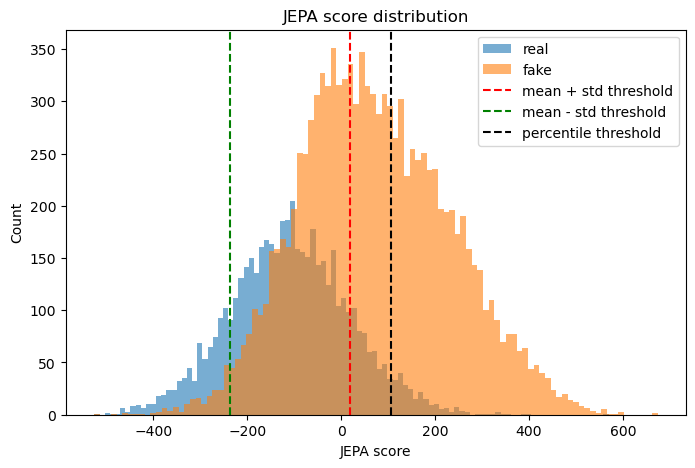

In [12]:
real_scores = val_jepa_scores.score

plt.figure(figsize=(8,5))

plt.hist(real_scores, bins=100, alpha=0.6, label="real")
plt.hist(test_results.score, bins=100, alpha=0.6, label="fake")

plt.axvline(x=mean_plus_std, color="red", linestyle="--", label="mean + std threshold")
plt.axvline(x=mean_minus_std, color="green", linestyle="--", label="mean - std threshold")
plt.axvline(x=percentile, color="black", linestyle="--", label="percentile threshold")

plt.xlabel("JEPA score")
plt.ylabel("Count")
plt.title("JEPA score distribution")
plt.legend()

plt.show()

In [13]:
bottle = test_results[test_results["img_path"].str.contains("airplane")].copy()
bottle

,label,score,img_path,prediction_mean_plus_std,prediction_mean_minus_std,prediction_percentile
35,0.0,128.803436,./datasets/test_sets/CNNSpot/all/real_train_ai...,1,1,1
48,0.0,-42.453506,./datasets/test_sets/CNNSpot/all/real_train_ai...,0,1,0
63,1.0,313.014954,./datasets/test_sets/CNNSpot/all/fake_train_ai...,1,1,1
69,1.0,227.145065,./datasets/test_sets/CNNSpot/all/fake_train_ai...,1,1,1
71,0.0,-56.160835,./datasets/test_sets/CNNSpot/all/real_train_ai...,0,1,0
...,...,...,...,...,...,...
11039,0.0,28.633148,./datasets/test_sets/CNNSpot/all/real_train_ai...,1,1,0
11047,1.0,232.420441,./datasets/test_sets/CNNSpot/all/fake_train_ai...,1,1,1
11054,1.0,336.133423,./datasets/test_sets/CNNSpot/all/fake_train_ai...,1,1,1
11083,0.0,-69.264511,./datasets/test_sets/CNNSpot/all/real_train_ai...,0,1,0


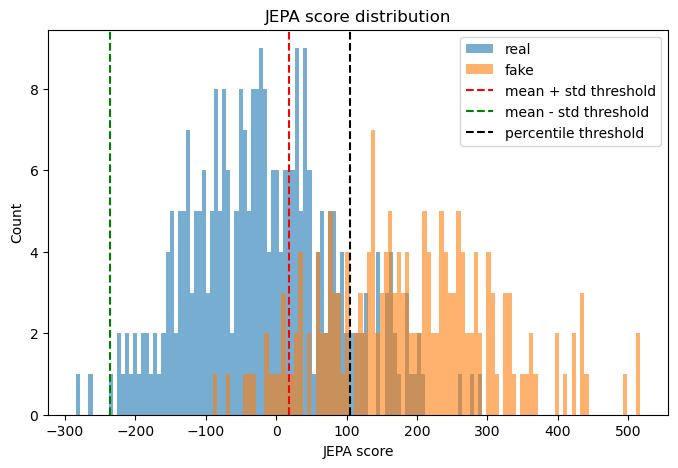

In [14]:
plt.figure(figsize=(8,5))

plt.hist(bottle[bottle["label"] == 0].score, bins=100, alpha=0.6, label="real")
plt.hist(bottle[bottle["label"] == 1].score, bins=100, alpha=0.6, label="fake")

plt.axvline(x=mean_plus_std, color="red", linestyle="--", label="mean + std threshold")
plt.axvline(x=mean_minus_std, color="green", linestyle="--", label="mean - std threshold")
plt.axvline(x=percentile, color="black", linestyle="--", label="percentile threshold")

plt.xlabel("JEPA score")
plt.ylabel("Count")
plt.title("JEPA score distribution")
plt.legend()

plt.show()